<a href="https://colab.research.google.com/github/Rakshitha443/ITA-0610-MACHINE-LEARNING-/blob/main/ML%20LAB%20LIST%20OF%20EXPERIMENTS(27/7/26).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1)

In [1]:
# =====================================================================
# MACHINE LEARNING: FIND-S ALGORITHM IMPLEMENTATION
# =====================================================================

import pandas as pd
import numpy as np

# 1. Define Training Dataset
# Features: [Sky, AirTemp, Humidity, Wind, Water, Forecast]
# Target: EnjoySport (Yes / No)
data = {
    'Sky': ['Sunny', 'Sunny', 'Rainy', 'Sunny'],
    'AirTemp': ['Warm', 'Warm', 'Cold', 'Warm'],
    'Humidity': ['Normal', 'High', 'High', 'High'],
    'Wind': ['Strong', 'Strong', 'Strong', 'Strong'],
    'Water': ['Warm', 'Warm', 'Warm', 'Cool'],
    'Forecast': ['Same', 'Same', 'Change', 'Same'],
    'EnjoySport': ['Yes', 'Yes', 'No', 'Yes']
}

df = pd.DataFrame(data)

# Separate features (X) and target label (y)
X = np.array(df.iloc[:, :-1])
y = np.array(df.iloc[:, -1])

# 2. FIND-S Algorithm Implementation
def find_s_algorithm(X, y):
    num_features = X.shape[1]

    # Step 1: Initialize the most specific hypothesis h_0 = ['0', '0', ..., '0']
    hypothesis = ['0'] * num_features

    print("=" * 70)
    print("                 FIND-S STEP-BY-STEP EXECUTION                 ")
    print("=" * 70)
    print(f"Initial Most Specific Hypothesis (h_0) : {hypothesis}\n")

    # Step 2: Iterate through all training samples
    for i, (instance, label) in enumerate(zip(X, y)):
        # FIND-S only considers positive instances
        if label == 'Yes' or label == 1:
            print(f"Sample {i+1} [POSITIVE]: {list(instance)}")

            # Initialize with first positive instance if hypothesis is still '0'
            for j in range(num_features):
                if hypothesis[j] == '0':
                    hypothesis[j] = instance[j]
                elif hypothesis[j] != instance[j]:
                    # Generalize the feature attribute to '?'
                    hypothesis[j] = '?'

            print(f"  --> Updated Hypothesis (h_{i+1}) : {hypothesis}\n")
        else:
            print(f"Sample {i+1} [NEGATIVE]: {list(instance)}")
            print(f"  --> Ignored by FIND-S (h_{i+1})  : {hypothesis}\n")

    return hypothesis

# 3. Run Algorithm
final_hypothesis = find_s_algorithm(X, y)

print("=" * 70)
print("                    FINAL TARGET HYPOTHESIS                    ")
print("=" * 70)
print(f"Most Specific Hypothesis (h_final): {final_hypothesis}")
print("=" * 70)

                 FIND-S STEP-BY-STEP EXECUTION                 
Initial Most Specific Hypothesis (h_0) : ['0', '0', '0', '0', '0', '0']

Sample 1 [POSITIVE]: ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same']
  --> Updated Hypothesis (h_1) : ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same']

Sample 2 [POSITIVE]: ['Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same']
  --> Updated Hypothesis (h_2) : ['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']

Sample 3 [NEGATIVE]: ['Rainy', 'Cold', 'High', 'Strong', 'Warm', 'Change']
  --> Ignored by FIND-S (h_3)  : ['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']

Sample 4 [POSITIVE]: ['Sunny', 'Warm', 'High', 'Strong', 'Cool', 'Same']
  --> Updated Hypothesis (h_4) : ['Sunny', 'Warm', '?', 'Strong', '?', 'Same']

                    FINAL TARGET HYPOTHESIS                    
Most Specific Hypothesis (h_final): ['Sunny', 'Warm', '?', 'Strong', '?', 'Same']


2)


In [2]:
# =====================================================================
# MACHINE LEARNING: CANDIDATE-ELIMINATION ALGORITHM
# =====================================================================

import os
import numpy as np
import pandas as pd

# 1. CREATE A SAMPLE CSV FILE
csv_data = """Sky,AirTemp,Humidity,Wind,Water,Forecast,EnjoySport
Sunny,Warm,Normal,Strong,Warm,Same,Yes
Sunny,Warm,High,Strong,Warm,Same,Yes
Rainy,Cold,High,Strong,Warm,Change,No
Sunny,Warm,High,Strong,Cool,Same,Yes"""

csv_filename = "training_data.csv"
with open(csv_filename, "w") as f:
  f.write(csv_data)


# 2. CANDIDATE-ELIMINATION ALGORITHM FUNCTION
def candidate_elimination(csv_path):
  # Read CSV file
  df = pd.read_csv(csv_path)

  # Extract feature matrix (X) and target array (y)
  X = np.array(df.iloc[:, :-1])
  y = np.array(df.iloc[:, -1])

  num_features = X.shape[1]

  # Initialize Specific Boundary (S) and General Boundary (G)
  S = ["0"] * num_features
  G = [["?"] * num_features]

  print("=" * 75)
  print("            CANDIDATE-ELIMINATION STEP-BY-STEP EXECUTION            ")
  print("=" * 75)
  print(f"Initial S_0 : {S}")
  print(f"Initial G_0 : {G}\n")

  # Process each training instance
  for i, (instance, label) in enumerate(zip(X, y)):
    print("-" * 75)
    print(f"Instance {i+1}: {list(instance)} | Target: {label}")

    if label.strip().lower() == "yes":
      # -------------------------------------------------------------
      # HANDLE POSITIVE INSTANCE
      # -------------------------------------------------------------
      # Remove from G any hypothesis inconsistent with instance
      G = [
          g
          for g in G
          if all(g[j] == "?" or g[j] == instance[j] for j in range(num_features))
      ]

      # Generalize S to cover instance
      for j in range(num_features):
        if S[j] == "0":
          S[j] = instance[j]
        elif S[j] != instance[j]:
          S[j] = "?"

    elif label.strip().lower() == "no":
      # -------------------------------------------------------------
      # HANDLE NEGATIVE INSTANCE
      # -------------------------------------------------------------
      # Remove from S any hypothesis that covers instance (S remains consistent)
      # Specialize G to exclude instance while staying consistent with S
      new_G = []
      for g in G:
        if all(
            g[j] == "?" or g[j] == instance[j] for j in range(num_features)
        ):
          for j in range(num_features):
            if g[j] == "?":
              if instance[j] != S[j] and S[j] != "?":
                g_spec = g.copy()
                g_spec[j] = S[j]
                new_G.append(g_spec)
        else:
          new_G.append(g)

      # Remove duplicate/subsumed hypotheses in G
      G = []
      for g in new_G:
        if not any(
            g != other
            and all(
                other[k] == "?" or other[k] == g[k] for k in range(num_features)
            )
            for other in new_G
        ):
          if g not in G:
            G.append(g)

    print(f"S_{i+1} : {S}")
    print(f"G_{i+1} : {G}")

  return S, G


# 3. RUN ALGORITHM
S_final, G_final = candidate_elimination(csv_filename)

print("\n" + "=" * 75)
print("                       FINAL VERSION SPACE                         ")
print("=" * 75)
print(f"Most Specific Boundary (S_final) : {S_final}")
print(f"Most General Boundary  (G_final) : {G_final}")
print("=" * 75)

            CANDIDATE-ELIMINATION STEP-BY-STEP EXECUTION            
Initial S_0 : ['0', '0', '0', '0', '0', '0']
Initial G_0 : [['?', '?', '?', '?', '?', '?']]

---------------------------------------------------------------------------
Instance 1: ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same'] | Target: Yes
S_1 : ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same']
G_1 : [['?', '?', '?', '?', '?', '?']]
---------------------------------------------------------------------------
Instance 2: ['Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same'] | Target: Yes
S_2 : ['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']
G_2 : [['?', '?', '?', '?', '?', '?']]
---------------------------------------------------------------------------
Instance 3: ['Rainy', 'Cold', 'High', 'Strong', 'Warm', 'Change'] | Target: No
S_3 : ['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']
G_3 : [['Sunny', '?', '?', '?', '?', '?'], ['?', 'Warm', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', 'Same']]
------------

3)

In [3]:
# =====================================================================
# MACHINE LEARNING: ID3 DECISION TREE FROM SCRATCH
# =====================================================================

import numpy as np
import pandas as pd

# 1. CREATE DATASET
data = {
    "Outlook": [
        "Sunny",
        "Sunny",
        "Overcast",
        "Rain",
        "Rain",
        "Rain",
        "Overcast",
        "Sunny",
        "Sunny",
        "Rain",
        "Sunny",
        "Overcast",
        "Overcast",
        "Rain",
    ],
    "Temperature": [
        "Hot",
        "Hot",
        "Hot",
        "Mild",
        "Cool",
        "Cool",
        "Cool",
        "Mild",
        "Cool",
        "Mild",
        "Mild",
        "Mild",
        "Hot",
        "Mild",
    ],
    "Humidity": [
        "High",
        "High",
        "High",
        "High",
        "Normal",
        "Normal",
        "Normal",
        "High",
        "Normal",
        "Normal",
        "Normal",
        "High",
        "Normal",
        "High",
    ],
    "Wind": [
        "Weak",
        "Strong",
        "Weak",
        "Weak",
        "Weak",
        "Strong",
        "Strong",
        "Weak",
        "Weak",
        "Weak",
        "Strong",
        "Strong",
        "Weak",
        "Strong",
    ],
    "PlayTennis": [
        "No",
        "No",
        "Yes",
        "Yes",
        "Yes",
        "No",
        "Yes",
        "No",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "No",
    ],
}

df = pd.DataFrame(data)


# 2. HELPER FUNCTIONS: ENTROPY AND INFORMATION GAIN
def calculate_entropy(target_col):
  elements, counts = np.unique(target_col, return_counts=True)
  entropy = 0.0
  for count in counts:
    p = count / len(target_col)
    entropy -= p * np.log2(p)
  return entropy


def calculate_information_gain(data, split_attribute, target_attribute):
  total_entropy = calculate_entropy(data[target_attribute])
  vals, counts = np.unique(data[split_attribute], return_counts=True)

  weighted_entropy = 0.0
  for val, count in zip(vals, counts):
    subset = data[data[split_attribute] == val]
    sub_entropy = calculate_entropy(subset[target_attribute])
    weighted_entropy += (count / len(data)) * sub_entropy

  info_gain = total_entropy - weighted_entropy
  return info_gain


# 3. RECURSIVE ID3 ALGORITHM
def id3(data, original_data, features, target_attribute="PlayTennis"):
  # Base Case 1: If all target values are identical, return that label
  unique_targets = np.unique(data[target_attribute])
  if len(unique_targets) == 1:
    return unique_targets[0]

  # Base Case 2: If dataset is empty, return majority class of original dataset
  elif len(data) == 0:
    vals, counts = np.unique(
        original_data[target_attribute], return_counts=True
    )
    return vals[np.argmax(counts)]

  # Base Case 3: If no features left, return majority class of current dataset
  elif len(features) == 0:
    vals, counts = np.unique(data[target_attribute], return_counts=True)
    return vals[np.argmax(counts)]

  # Recursive Case: Select best feature with maximum Information Gain
  gains = [
      calculate_information_gain(data, f, target_attribute) for f in features
  ]
  best_feature_idx = np.argmax(gains)
  best_feature = features[best_feature_idx]

  # Build tree node
  tree = {best_feature: {}}
  remaining_features = [f for f in features if f != best_feature]

  # Split tree on values of best feature
  for val in np.unique(data[best_feature]):
    sub_data = data[data[best_feature] == val]
    subtree = id3(
        sub_data, original_data, remaining_features, target_attribute
    )
    tree[best_feature][val] = subtree

  return tree


# 4. CLASSIFICATION FUNCTION FOR NEW SAMPLE
def predict(tree, sample):
  for node in tree.keys():
    val = sample.get(node)
    if val in tree[node]:
      subtree = tree[node][val]
      if isinstance(subtree, dict):
        return predict(subtree, sample)
      else:
        return subtree
    else:
      return "Unknown branch"


# 5. EXECUTION & DEMONSTRATION
features = list(df.columns[:-1])
decision_tree = id3(df, df, features)

print("=" * 70)
print("                    BUILT ID3 DECISION TREE                    ")
print("=" * 70)
import json

print(json.dumps(decision_tree, indent=4))

# Define new unseen sample
new_sample = {
    "Outlook": "Rain",
    "Temperature": "Cool",
    "Humidity": "Normal",
    "Wind": "Strong",
}

prediction = predict(decision_tree, new_sample)

print("\n" + "=" * 70)
print("                   CLASSIFYING NEW SAMPLE                      ")
print("=" * 70)
print(f"Sample Features : {new_sample}")
print(f"Predicted Class : PlayTennis = {prediction}")
print("=" * 70)

                    BUILT ID3 DECISION TREE                    
{
    "Outlook": {
        "Overcast": "Yes",
        "Rain": {
            "Wind": {
                "Strong": "No",
                "Weak": "Yes"
            }
        },
        "Sunny": {
            "Humidity": {
                "High": "No",
                "Normal": "Yes"
            }
        }
    }
}

                   CLASSIFYING NEW SAMPLE                      
Sample Features : {'Outlook': 'Rain', 'Temperature': 'Cool', 'Humidity': 'Normal', 'Wind': 'Strong'}
Predicted Class : PlayTennis = No


4)


             STARTING BACKPROPAGATION TRAINING LOOP             
Epoch  2000 | Loss (MSE): 0.091855
Epoch  4000 | Loss (MSE): 0.011112
Epoch  6000 | Loss (MSE): 0.002716
Epoch  8000 | Loss (MSE): 0.001424
Epoch 10000 | Loss (MSE): 0.000945

                   MODEL EVALUATION ON XOR                      
Input (X1, X2) | Target (y) | Predicted Prob | Binary Output
----------------------------------------------------------------------
   0   ,   0   |     0      |     0.0440     |       0
   0   ,   1   |     1      |     0.9543     |       1
   1   ,   0   |     1      |     0.9621     |       1
   1   ,   1   |     0      |     0.0458     |       0


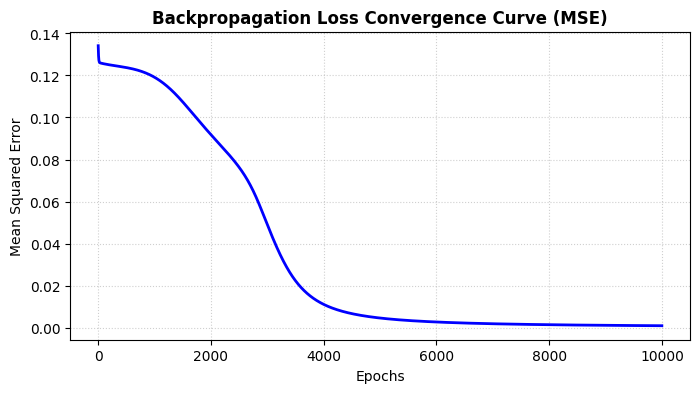

In [4]:
# =====================================================================
# ARTIFICIAL NEURAL NETWORK WITH BACKPROPAGATION FROM SCRATCH
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np


class NeuralNetwork:

  def __init__(self, input_dim, hidden_dim, output_dim, lr=0.1):
    self.lr = lr

    # Initialize weights with Xavier/Glorot initialization & zero-initialize biases
    np.random.seed(42)
    self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
    self.b1 = np.zeros((1, hidden_dim))
    self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(
        2.0 / hidden_dim
    )
    self.b2 = np.zeros((1, output_dim))

  # Activation function & its derivative
  def sigmoid(self, z):
    return 1.0 / (1.0 + np.exp(-z))

  def sigmoid_derivative(self, a):
    return a * (1.0 - a)

  # Forward Pass
  def forward(self, X):
    self.z1 = np.dot(X, self.W1) + self.b1
    self.a1 = self.sigmoid(self.z1)

    self.z2 = np.dot(self.a1, self.W2) + self.b2
    self.a2 = self.sigmoid(self.z2)
    return self.a2

  # Backward Pass
  def backward(self, X, y, output):
    m = X.shape[0]

    # Output layer error delta: dL/dz2
    delta2 = (output - y) * self.sigmoid_derivative(output)
    dW2 = np.dot(self.a1.T, delta2) / m
    db2 = np.sum(delta2, axis=0, keepdims=True) / m

    # Hidden layer error delta: dL/dz1
    delta1 = np.dot(delta2, self.W2.T) * self.sigmoid_derivative(self.a1)
    dW1 = np.dot(X.T, delta1) / m
    db1 = np.sum(delta1, axis=0, keepdims=True) / m

    # Gradient Descent Parameter Update
    self.W2 -= self.lr * dW2
    self.b2 -= self.lr * db2
    self.W1 -= self.lr * dW1
    self.b1 -= self.lr * db1

  # Training Loop
  def train(self, X, y, epochs=10000):
    losses = []
    for epoch in range(epochs):
      output = self.forward(X)
      loss = np.mean(0.5 * (y - output) ** 2)  # Mean Squared Error
      losses.append(loss)

      self.backward(X, y, output)

      if (epoch + 1) % 2000 == 0:
        print(f"Epoch {epoch+1:5d} | Loss (MSE): {loss:.6f}")

    return losses


# =====================================================================
# TESTING THE MODEL ON THE NON-LINEAR XOR DATASET
# =====================================================================

# XOR Input & Expected Output
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

# Initialize and train network (2 Inputs, 4 Hidden Neurons, 1 Output)
nn = NeuralNetwork(input_dim=2, hidden_dim=4, output_dim=1, lr=0.5)

print("=" * 70)
print("             STARTING BACKPROPAGATION TRAINING LOOP             ")
print("=" * 70)
history_loss = nn.train(X, y, epochs=10000)

# Evaluate predictions
predictions = nn.forward(X)
binary_preds = (predictions > 0.5).astype(int)

print("\n" + "=" * 70)
print("                   MODEL EVALUATION ON XOR                      ")
print("=" * 70)
print("Input (X1, X2) | Target (y) | Predicted Prob | Binary Output")
print("-" * 70)
for i in range(len(X)):
  print(
      f"   {X[i][0]}   ,   {X[i][1]}   |     {y[i][0]}      |     {predictions[i][0]:.4f}     |       {binary_preds[i][0]}"
  )
print("=" * 70)

# Plot Loss Curve
plt.figure(figsize=(8, 4))
plt.plot(history_loss, color="blue", linewidth=2)
plt.title("Backpropagation Loss Convergence Curve (MSE)", fontweight="bold")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

5)

In [5]:
# =====================================================================
# MACHINE LEARNING: K-NEAREST NEIGHBOURS (K-NN) FROM SCRATCH
# =====================================================================

from collections import Counter
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


# 1. K-NN CLASSIFIER IMPLEMENTATION FROM SCRATCH
class KNNFromScratch:

  def __init__(self, k=3):
    self.k = k

  def fit(self, X_train, y_train):
    """Store training data (Lazy Learner)."""
    self.X_train = np.array(X_train)
    self.y_train = np.array(y_train)

  def _euclidean_distance(self, x1, x2):
    """Compute Euclidean distance between two feature vectors."""
    return np.sqrt(np.sum((x1 - x2) ** 2))

  def predict(self, X_test):
    """Predict target labels for test dataset."""
    X_test = np.array(X_test)
    predictions = [self._predict_single(x) for x in X_test]
    return np.array(predictions)

  def _predict_single(self, x):
    # Step 1: Calculate distances to all training points
    distances = [
        self._euclidean_distance(x, x_train) for x_train in self.X_train
    ]

    # Step 2: Get indices of the k-nearest neighbors
    k_indices = np.argsort(distances)[: self.k]

    # Step 3: Extract labels of the k-nearest neighbors
    k_nearest_labels = [self.y_train[i] for i in k_indices]

    # Step 4: Majority vote for class prediction
    most_common = Counter(k_nearest_labels).most_common(1)
    return most_common[0][0]


# =====================================================================
# DEMONSTRATION & PERFORMANCE COMPARISON
# =====================================================================

# Load Iris Dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Set K parameter
K = 5

# --- Run K-NN From Scratch ---
knn_custom = KNNFromScratch(k=K)
knn_custom.fit(X_train, y_train)
custom_preds = knn_custom.predict(X_test)
custom_acc = accuracy_score(y_test, custom_preds)

# --- Run Scikit-Learn K-NN ---
knn_sklearn = KNeighborsClassifier(n_neighbors=K)
knn_sklearn.fit(X_train, y_train)
sklearn_preds = knn_sklearn.predict(X_test)
sklearn_acc = accuracy_score(y_test, sklearn_preds)

# =====================================================================
# DISPLAY RESULTS
# =====================================================================
print("=" * 65)
print(f"      K-NEAREST NEIGHBOURS PERFORMANCE COMPARISON (K = {K})      ")
print("=" * 65)
print(f"Accuracy (Custom K-NN from Scratch) : {custom_acc * 100:.2f}%")
print(f"Accuracy (Scikit-Learn K-NN)       : {sklearn_acc * 100:.2f}%")
print("-" * 65)

print("\nCONFUSION MATRIX (Custom K-NN):")
print(confusion_matrix(y_test, custom_preds))

print("\nCLASSIFICATION REPORT:")
print(
    classification_report(y_test, custom_preds, target_names=iris.target_names)
)
print("=" * 65)

# Predict on a New Unseen Sample
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])  # Expected: Setosa
predicted_class_id = knn_custom.predict(new_sample)[0]
predicted_class_name = iris.target_names[predicted_class_id]

print("\n" + "=" * 65)
print("                   CLASSIFYING NEW SAMPLE                      ")
print("=" * 65)
print(f"Sample Features : {new_sample[0]}")
print(
    f"Predicted Class : Class {predicted_class_id} ({predicted_class_name})"
)
print("=" * 65)

      K-NEAREST NEIGHBOURS PERFORMANCE COMPARISON (K = 5)      
Accuracy (Custom K-NN from Scratch) : 100.00%
Accuracy (Scikit-Learn K-NN)       : 100.00%
-----------------------------------------------------------------

CONFUSION MATRIX (Custom K-NN):
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


                   CLASSIFYING NEW SAMPLE                      
Sample Features : [5.1 3.5 1.4 0.2]
Predicted Class : Class 0 (setosa)


6)

In [6]:
# =====================================================================
# MACHINE LEARNING: GAUSSIAN NAÏVE BAYES FROM SCRATCH
# =====================================================================

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB


# 1. NAÏVE BAYES CLASSIFIER IMPLEMENTATION FROM SCRATCH
class NaiveBayesFromScratch:

  def fit(self, X, y):
    n_samples, n_features = X.shape
    self.classes = np.unique(y)
    n_classes = len(self.classes)

    # Initialize mean, variance, and prior probabilities for each class
    self.mean = np.zeros((n_classes, n_features))
    self.var = np.zeros((n_classes, n_features))
    self.priors = np.zeros(n_classes)

    for idx, c in enumerate(self.classes):
      X_c = X[y == c]
      self.mean[idx, :] = X_c.mean(axis=0)
      self.var[idx, :] = X_c.var(axis=0) + 1e-9  # Add epsilon to prevent div-by-zero
      self.priors[idx] = X_c.shape[0] / float(n_samples)

  def predict(self, X):
    return np.array([self._predict_single(x) for x in X])

  def _predict_single(self, x):
    posteriors = []

    # Calculate log posterior probability for each class: log(P(y)) + sum(log(P(x_i|y)))
    for idx, c in enumerate(self.classes):
      prior = np.log(self.priors[idx])
      conditional = np.sum(
          np.log(self._gaussian_pdf(idx, x))
      )  # Sum in log space = product in standard space
      posterior = prior + conditional
      posteriors.append(posterior)

    # Return class with highest posterior probability
    return self.classes[np.argmax(posteriors)]

  def _gaussian_pdf(self, class_idx, x):
    mean = self.mean[class_idx]
    var = self.var[class_idx]
    numerator = np.exp(-((x - mean) ** 2) / (2 * var))
    denominator = np.sqrt(2 * np.pi * var)
    return numerator / denominator


# =====================================================================
# DEMONSTRATION & EVALUATION
# =====================================================================

# 1. Load Iris Dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Train & Evaluate Custom Model
nb_custom = NaiveBayesFromScratch()
nb_custom.fit(X_train, y_train)
y_pred_custom = nb_custom.predict(X_test)

# 4. Train & Evaluate Scikit-Learn Model
nb_sklearn = GaussianNB()
nb_sklearn.fit(X_train, y_train)
y_pred_sklearn = nb_sklearn.predict(X_test)

# =====================================================================
# DISPLAY RESULTS
# =====================================================================
accuracy_custom = accuracy_score(y_test, y_pred_custom)
accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)
cm_custom = confusion_matrix(y_test, y_pred_custom)

print("=" * 65)
print("             GAUSSIAN NAÏVE BAYES RESULTS SUMMARY               ")
print("=" * 65)
print(f"Accuracy Score (Custom Model) : {accuracy_custom * 100:.2f}%")
print(f"Accuracy Score (Scikit-Learn) : {accuracy_sklearn * 100:.2f}%")
print("-" * 65)

print("\nCONFUSION MATRIX (Custom Model):")
print("---------------------------------")
cm_df = pd.DataFrame(
    cm_custom, index=iris.target_names, columns=iris.target_names
)
print(cm_df)

print("\nCLASSIFICATION REPORT:")
print("----------------------")
print(
    classification_report(
        y_test, y_pred_custom, target_names=iris.target_names
    )
)
print("=" * 65)

# Predict on a New Sample
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])  # Expected: Setosa
prediction = nb_custom.predict(new_sample)[0]

print("\n" + "=" * 65)
print("                   CLASSIFYING NEW SAMPLE                      ")
print("=" * 65)
print(f"Sample Features : {new_sample[0]}")
print(
    f"Predicted Class : Class {prediction} ({iris.target_names[prediction]})"
)
print("=" * 65)

             GAUSSIAN NAÏVE BAYES RESULTS SUMMARY               
Accuracy Score (Custom Model) : 96.67%
Accuracy Score (Scikit-Learn) : 96.67%
-----------------------------------------------------------------

CONFUSION MATRIX (Custom Model):
---------------------------------
            setosa  versicolor  virginica
setosa          10           0          0
versicolor       0           9          1
virginica        0           0         10

CLASSIFICATION REPORT:
----------------------
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


                   CLASSIFYING NEW SAMPLE                      
Sample Features : [5.1 3.5 1.4 0.2]
Predicted Class : Class 0 

7)


In [7]:
# =====================================================================
# MACHINE LEARNING: LOGISTIC REGRESSION FROM SCRATCH
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split


# 1. LOGISTIC REGRESSION CLASS IMPLEMENTATION
class LogisticRegressionFromScratch:

  def __init__(self, learning_rate=0.01, num_iterations=1000):
    self.lr = learning_rate
    self.num_iterations = num_iterations
    self.weights = None
    self.bias = None
    self.losses = []

  def _sigmoid(self, z):
    # Clip z to avoid overflow in exp
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

  def fit(self, X, y):
    m_samples, n_features = X.shape

    # Initialize parameters
    self.weights = np.zeros(n_features)
    self.bias = 0.0

    # Gradient Descent Optimization Loop
    for i in range(self.num_iterations):
      # Linear Combination
      linear_model = np.dot(X, self.weights) + self.bias
      # Apply Sigmoid Activation
      y_predicted = self._sigmoid(linear_model)

      # Compute Binary Cross-Entropy Loss
      epsilon = 1e-15  # Avoid log(0)
      y_pred_clipped = np.clip(y_predicted, epsilon, 1 - epsilon)
      loss = -np.mean(
          y * np.log(y_pred_clipped) + (1 - y) * np.log(1 - y_pred_clipped)
      )
      self.losses.append(loss)

      # Compute Gradients
      dw = (1 / m_samples) * np.dot(X.T, (y_predicted - y))
      db = (1 / m_samples) * np.sum(y_predicted - y)

      # Update Parameters
      self.weights -= self.lr * dw
      self.bias -= self.lr * db

      if (i + 1) % (self.num_iterations // 5) == 0:
        print(f"Iteration {i+1:5d} | Loss: {loss:.4f}")

  def predict_proba(self, X):
    linear_model = np.dot(X, self.weights) + self.bias
    return self._sigmoid(linear_model)

  def predict(self, X, threshold=0.5):
    y_predicted_cls = [
        1 if i >= threshold else 0 for i in self.predict_proba(X)
    ]
    return np.array(y_predicted_cls)


# =====================================================================
# DEMONSTRATION & PERFORMANCE COMPARISON
# =====================================================================

# 1. Generate Synthetic Binary Classification Dataset
X, y = make_classification(
    n_samples=1000,
    n_features=4,
    n_informative=3,
    n_redundant=1,
    random_state=42,
)

# 2. Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Train Custom Logistic Regression Model
print("=" * 65)
print("          TRAINING LOGISTIC REGRESSION (FROM SCRATCH)          ")
print("=" * 65)
custom_lr = LogisticRegressionFromScratch(learning_rate=0.1, num_iterations=1000)
custom_lr.fit(X_train, y_train)

custom_preds = custom_lr.predict(X_test)
custom_acc = accuracy_score(y_test, custom_preds)

# 4. Train Scikit-Learn Model for Comparison
sklearn_lr = SklearnLogisticRegression()
sklearn_lr.fit(X_train, y_train)
sklearn_preds = sklearn_lr.predict(X_test)
sklearn_acc = accuracy_score(y_test, sklearn_preds)

# =====================================================================
# DISPLAY RESULTS
# =====================================================================
print("\n" + "=" * 65)
print("             LOGISTIC REGRESSION PERFORMANCE RESULTS            ")
print("=" * 65)
print(f"Accuracy (Custom LR from Scratch) : {custom_acc * 100:.2f}%")
print(f"Accuracy (Scikit-Learn LR)       : {sklearn_acc * 100:.2f}%")
print("-" * 65)

print("\nCONFUSION MATRIX (Custom Model):")
print(confusion_matrix(y_test, custom_preds))

print("\nCLASSIFICATION REPORT:")
print(
    classification_report(y_test, custom_preds, target_names=["Class 0", "Class 1"])
)
print("=" * 65)

# Predict on a New Unseen Sample
new_sample = np.array([[0.5, -1.2, 0.8, 1.1]])
prob = custom_lr.predict_proba(new_sample)[0]
pred_class = custom_lr.predict(new_sample)[0]

print("\n" + "=" * 65)
print("                   CLASSIFYING NEW SAMPLE                      ")
print("=" * 65)
print(f"Sample Features     : {new_sample[0]}")
print(f"Predicted Probability: {prob:.4f}")
print(f"Predicted Class      : {pred_class}")
print("=" * 65)

          TRAINING LOGISTIC REGRESSION (FROM SCRATCH)          
Iteration   200 | Loss: 0.2298
Iteration   400 | Loss: 0.2161
Iteration   600 | Loss: 0.2126
Iteration   800 | Loss: 0.2113
Iteration  1000 | Loss: 0.2108

             LOGISTIC REGRESSION PERFORMANCE RESULTS            
Accuracy (Custom LR from Scratch) : 90.00%
Accuracy (Scikit-Learn LR)       : 90.00%
-----------------------------------------------------------------

CONFUSION MATRIX (Custom Model):
[[91 10]
 [10 89]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     Class 0       0.90      0.90      0.90       101
     Class 1       0.90      0.90      0.90        99

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200


                   CLASSIFYING NEW SAMPLE                      
Sample Features     : [ 0.5 -1.2  0.8  1.1]
Predicted Probability: 0.7478
Predicted Class      

8)


In [8]:
# =====================================================================
# MACHINE LEARNING: LINEAR REGRESSION FROM SCRATCH
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression as SklearnLinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


# 1. LINEAR REGRESSION CLASS (GRADIENT DESCENT & OLS)
class LinearRegressionFromScratch:

  def __init__(self, learning_rate=0.01, num_iterations=1000):
    self.lr = learning_rate
    self.num_iterations = num_iterations
    self.weights = None
    self.bias = None
    self.losses = []

  def fit_gradient_descent(self, X, y):
    """Train using Gradient Descent."""
    m_samples, n_features = X.shape

    # Initialize weights and bias to zeros
    self.weights = np.zeros(n_features)
    self.bias = 0.0

    # Optimization Loop
    for i in range(self.num_iterations):
      # Forward prediction
      y_predicted = np.dot(X, self.weights) + self.bias

      # Calculate Mean Squared Error Loss
      loss = np.mean((y - y_predicted) ** 2)
      self.losses.append(loss)

      # Compute Gradients
      dw = (-2 / m_samples) * np.dot(X.T, (y - y_predicted))
      db = (-2 / m_samples) * np.sum(y - y_predicted)

      # Update Parameters
      self.weights -= self.lr * dw
      self.bias -= self.lr * db

      if (i + 1) % (self.num_iterations // 5) == 0:
        print(f"Iteration {i+1:5d} | MSE Loss: {loss:.4f}")

  def fit_ols(self, X, y):
    """Train using Closed-Form Ordinary Least Squares (OLS)."""
    # Add column of 1s for bias term: X_b = [1, X]
    X_b = np.c_[np.ones((X.shape[0], 1)), X]

    # Matrix formula: theta = (X_b^T * X_b)^(-1) * X_b^T * y
    theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

    self.bias = theta[0]
    self.weights = theta[1:]

  def predict(self, X):
    """Predict continuous target values."""
    return np.dot(X, self.weights) + self.bias


# =====================================================================
# DEMONSTRATION & EVALUATION
# =====================================================================

# 1. Generate Synthetic Regression Dataset
X, y = make_regression(
    n_samples=500, n_features=2, noise=15, random_state=42
)

# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Train Custom Linear Regression Model (Gradient Descent)
print("=" * 65)
print("         TRAINING LINEAR REGRESSION (GRADIENT DESCENT)         ")
print("=" * 65)
custom_lr = LinearRegressionFromScratch(
    learning_rate=0.05, num_iterations=1000
)
custom_lr.fit_gradient_descent(X_train, y_train)

preds_gd = custom_lr.predict(X_test)
mse_gd = mean_squared_error(y_test, preds_gd)
r2_gd = r2_score(y_test, preds_gd)

# 4. Train Custom Model using Closed-Form OLS
custom_lr_ols = LinearRegressionFromScratch()
custom_lr_ols.fit_ols(X_train, y_train)
preds_ols = custom_lr_ols.predict(X_test)
mse_ols = mean_squared_error(y_test, preds_ols)
r2_ols = r2_score(y_test, preds_ols)

# 5. Train Scikit-Learn Model for Comparison
sklearn_lr = SklearnLinearRegression()
sklearn_lr.fit(X_train, y_train)
preds_sklearn = sklearn_lr.predict(X_test)
mse_sklearn = mean_squared_error(y_test, preds_sklearn)
r2_sklearn = r2_score(y_test, preds_sklearn)

# =====================================================================
# DISPLAY RESULTS
# =====================================================================
print("\n" + "=" * 65)
print("             LINEAR REGRESSION PERFORMANCE RESULTS              ")
print("=" * 65)
print(f"Gradient Descent MSE : {mse_gd:.4f}  |  R² Score: {r2_gd:.4f}")
print(f"Closed-Form OLS MSE  : {mse_ols:.4f}  |  R² Score: {r2_ols:.4f}")
print(
    f"Scikit-Learn MSE     : {mse_sklearn:.4f}  |  R² Score: {r2_sklearn:.4f}"
)
print("=" * 65)

# Predict on a New Unseen Sample
new_sample = np.array([[1.5, -0.8]])
prediction = custom_lr.predict(new_sample)[0]

print("\n" + "=" * 65)
print("                   PREDICTING NEW SAMPLE                       ")
print("=" * 65)
print(f"Sample Features : {new_sample[0]}")
print(f"Predicted Value : {prediction:.4f}")
print("=" * 65)

         TRAINING LINEAR REGRESSION (GRADIENT DESCENT)         
Iteration   200 | MSE Loss: 236.6892
Iteration   400 | MSE Loss: 236.6892
Iteration   600 | MSE Loss: 236.6892
Iteration   800 | MSE Loss: 236.6892
Iteration  1000 | MSE Loss: 236.6892

             LINEAR REGRESSION PERFORMANCE RESULTS              
Gradient Descent MSE : 196.1327  |  R² Score: 0.6383
Closed-Form OLS MSE  : 196.1327  |  R² Score: 0.6383
Scikit-Learn MSE     : 196.1327  |  R² Score: 0.6383

                   PREDICTING NEW SAMPLE                       
Sample Features : [ 1.5 -0.8]
Predicted Value : 5.6252


9)

             MODEL PERFORMANCE COMPARISON TABLE                  
                 Model      MSE  R² Score
     Linear (Degree 1) 3.024564  0.426008
 Polynomial (Degree 2) 0.777194  0.852507
Polynomial (Degree 10) 0.739909  0.859583


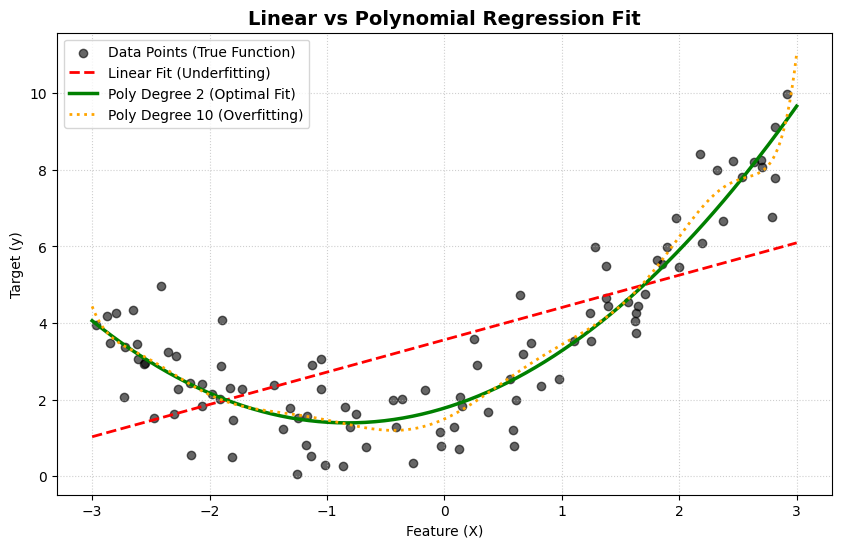

In [9]:
# =====================================================================
# COMPARISON: LINEAR VS POLYNOMIAL REGRESSION
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

# 1. GENERATE NON-LINEAR SYNTHETIC DATASET (Quadratic Curve + Noise)
np.random.seed(42)
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1)

# Sort X for clean plotting lines
sort_idx = np.argsort(X.flatten())
X_plot = X[sort_idx]
y_plot = y[sort_idx]

# 2. MODEL 1: LINEAR REGRESSION
linear_model = LinearRegression()
linear_model.fit(X, y)
y_pred_linear = linear_model.predict(X)

# 3. MODEL 2: POLYNOMIAL REGRESSION (DEGREE 2)
poly_features_2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly_2 = poly_features_2.fit_transform(X)

poly_model_2 = LinearRegression()
poly_model_2.fit(X_poly_2, y)
y_pred_poly_2 = poly_model_2.predict(X_poly_2)

# 4. MODEL 3: POLYNOMIAL REGRESSION (DEGREE 10 - OVERFITTING DEMO)
poly_features_10 = PolynomialFeatures(degree=10, include_bias=False)
X_poly_10 = poly_features_10.fit_transform(X)

poly_model_10 = LinearRegression()
poly_model_10.fit(X_poly_10, y)
y_pred_poly_10 = poly_model_10.predict(X_poly_10)

# 5. METRICS COMPUTATION
results = {
    "Model": ["Linear (Degree 1)", "Polynomial (Degree 2)", "Polynomial (Degree 10)"],
    "MSE": [
        mean_squared_error(y, y_pred_linear),
        mean_squared_error(y, y_pred_poly_2),
        mean_squared_error(y, y_pred_poly_10)
    ],
    "R² Score": [
        r2_score(y, y_pred_linear),
        r2_score(y, y_pred_poly_2),
        r2_score(y, y_pred_poly_10)
    ]
}

df_results = pd.DataFrame(results)

print("=" * 65)
print("             MODEL PERFORMANCE COMPARISON TABLE                  ")
print("=" * 65)
print(df_results.to_string(index=False))
print("=" * 65)

# 6. VISUALIZATION
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', alpha=0.6, label='Data Points (True Function)')

# Plot fits
X_seq = np.linspace(-3, 3, 300).reshape(-1, 1)
plt.plot(X_seq, linear_model.predict(X_seq), color='red', linestyle='--', linewidth=2, label='Linear Fit (Underfitting)')

X_seq_poly2 = poly_features_2.transform(X_seq)
plt.plot(X_seq, poly_model_2.predict(X_seq_poly2), color='green', linewidth=2.5, label='Poly Degree 2 (Optimal Fit)')

X_seq_poly10 = poly_features_10.transform(X_seq)
plt.plot(X_seq, poly_model_10.predict(X_seq_poly10), color='orange', linestyle=':', linewidth=2, label='Poly Degree 10 (Overfitting)')

plt.title('Linear vs Polynomial Regression Fit', fontsize=14, fontweight='bold')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

10)

In [10]:
# =====================================================================
# MACHINE LEARNING: EXPECTATION-MAXIMIZATION (EM) ALGORITHM FROM SCRATCH
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture


# 1. EM ALGORITHM FOR GAUSSIAN MIXTURE MODEL (GMM)
class GaussianMixtureEM:

  def __init__(self, n_components=2, max_iter=100, tol=1e-6):
    self.K = n_components
    self.max_iter = max_iter
    self.tol = tol

  def _gaussian_pdf(self, X, mean, var):
    """Compute 1D Gaussian Probability Density Function."""
    denominator = np.sqrt(2 * np.pi * var)
    numerator = np.exp(-((X - mean) ** 2) / (2 * var))
    return numerator / (denominator + 1e-9)

  def fit(self, X):
    X = np.asarray(X).ravel()
    N = len(X)

    # Step 1: Initialize Parameters (\mu, \sigma^2, \pi)
    np.random.seed(42)
    self.means = np.random.choice(X, self.K)
    self.vars = np.ones(self.K) * np.var(X)
    self.weights = np.ones(self.K) / self.K

    log_likelihoods = []

    for iteration in range(self.max_iter):
      # =========================================================
      # STEP 2: EXPECTATION STEP (E-STEP)
      # =========================================================
      # Compute likelihood matrix of shape (N, K)
      likelihoods = np.zeros((N, self.K))
      for k in range(self.K):
        likelihoods[:, k] = self._gaussian_pdf(
            X, self.means[k], self.vars[k]
        )

      # Weighted likelihoods
      weighted_likelihoods = likelihoods * self.weights

      # Marginal probability per sample
      sample_likelihoods = np.sum(weighted_likelihoods, axis=1)

      # Log-Likelihood for convergence check
      log_likelihood = np.sum(np.log(sample_likelihoods + 1e-9))
      log_likelihoods.append(log_likelihood)

      # Compute Responsibilities \gamma_{ik}
      responsibilities = weighted_likelihoods / (
          sample_likelihoods[:, np.newaxis] + 1e-9
      )

      # =========================================================
      # STEP 3: MAXIMIZATION STEP (M-STEP)
      # =========================================================
      # Effective number of points assigned to component k
      N_k = np.sum(responsibilities, axis=0)

      for k in range(self.K):
        # Update Means
        self.means[k] = np.sum(responsibilities[:, k] * X) / N_k[k]

        # Update Variances
        self.vars[k] = (
            np.sum(responsibilities[:, k] * (X - self.means[k]) ** 2) / N_k[k]
            + 1e-6
        )

        # Update Mixture Weights
        self.weights[k] = N_k[k] / N

      # Check for convergence
      if (
          iteration > 0
          and abs(log_likelihood - log_likelihoods[-2]) < self.tol
      ):
        print(f"EM converged at iteration {iteration + 1}")
        break

    self.responsibilities = responsibilities
    return self


# =====================================================================
# DEMONSTRATION & COMPARISON
# =====================================================================

# 1. Generate Synthetic Bimodal Data (2 Gaussian distributions)
np.random.seed(42)
cluster1 = np.random.normal(loc=-2.0, scale=0.8, size=300)
cluster2 = np.random.normal(loc=3.0, scale=1.2, size=500)
X = np.hstack([cluster1, cluster2])

# 2. Fit Custom EM Model
gmm_custom = GaussianMixtureEM(n_components=2, max_iter=100)
gmm_custom.fit(X)

# 3. Fit Scikit-Learn GaussianMixture Model
gmm_sklearn = GaussianMixture(n_components=2, random_state=42)
gmm_sklearn.fit(X.reshape(-1, 1))

# =====================================================================
# DISPLAY RESULTS
# =====================================================================
# Sort parameters for consistent comparison output
custom_idx = np.argsort(gmm_custom.means)
sklearn_idx = np.argsort(gmm_sklearn.means_.flatten())

comparison_df = pd.DataFrame({
    "Component": [f"Cluster {i+1}" for i in range(2)],
    "Custom Mean": gmm_custom.means[custom_idx],
    "Sklearn Mean": gmm_sklearn.means_.flatten()[sklearn_idx],
    "Custom Variance": gmm_custom.vars[custom_idx],
    "Sklearn Variance": gmm_sklearn.covariances_.flatten()[sklearn_idx],
    "Custom Weight": gmm_custom.weights[custom_idx],
    "Sklearn Weight": gmm_sklearn.weights_[sklearn_idx],
})

print("=" * 75)
print("              EXPECTATION-MAXIMIZATION (EM) RESULTS SUMMARY            ")
print("=" * 75)
print(comparison_df.to_string(index=False))
print("=" * 75)

# Predict Cluster Assignments
cluster_labels = np.argmax(gmm_custom.responsibilities, axis=1)
print(
    f"\nAssigned Samples to Cluster 0 : {np.sum(cluster_labels == custom_idx[0])}"
)
print(
    f"Assigned Samples to Cluster 1 : {np.sum(cluster_labels == custom_idx[1])}"
)

EM converged at iteration 16
              EXPECTATION-MAXIMIZATION (EM) RESULTS SUMMARY            
Component  Custom Mean  Sklearn Mean  Custom Variance  Sklearn Variance  Custom Weight  Sklearn Weight
Cluster 1    -2.025773     -2.023505         0.574392          0.577998        0.37107        0.371539
Cluster 2     2.970215      2.972601         1.442680          1.435963        0.62893        0.628461

Assigned Samples to Cluster 0 : 299
Assigned Samples to Cluster 1 : 501
